In [1]:
import warnings
import pandas as pd
from pandas.errors import SettingWithCopyWarning
warnings.simplefilter(action="ignore", category=pd.errors.SettingWithCopyWarning)
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
sns.set(style='whitegrid',font_scale=2)
import os
import math
import pickle
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)
os.chdir(os.getcwd())

## Description of data format
Create a dataset of patient drug regimens with the following structure:
|Pat_ID | Study_ID | Arm | Week | drug1 cc. | drug1 weekly_freq | drug2 cc.| drug2_weekly_freq.|
|-------|----------|-----|------|-----------|-------------------|----------|-------------------|
day1                       |          |     |      |           |                   |          |
day2                       |          |     |      |           |                   |          |
day3                       |          |     |      |           |                   |          |
...                       ...        ...   ...    ...         ...                 ...        ...
last th. day               |          |     |      |           |                   |          |

All patients are contained in one dataframe


In [7]:
# LOAD THE PATIENTS FOR ANALYSIS
patients_for_analyis=pd.read_csv('../data/patients_in_analysis.csv.gz',index_col=0)
pat_ids_for_anal=patients_for_analyis['USUBJID'].unique().tolist()
pat_regimens=pd.read_csv('../../C-Path_data/preprocessing/patient_regimens_updated_with_exposure.csv',low_memory=False,index_col=0)
com_ids=list(set(patients_for_analyis['USUBJID'])&set(pat_regimens.index))
pat_regimens=pat_regimens.loc[com_ids,:]
pat_regimens_=pat_regimens.reset_index()

# LOAD DRUG ADHERENCE DATASET
da=pd.read_csv('../../C-Path_data/fullExportDb-1025-Member-CSV/da.csv',low_memory=False)
da=da.dropna(how='all',axis=1)

# LOAD DISPOSITION DATASET
ds_all=pd.read_csv('../../C-Path_data/fullExportDb-1025-Member-CSV/ds.csv',low_memory=False)
ds=ds_all[ds_all['USUBJID'].isin(com_ids)]

disp_events_all=pd.read_csv('../../C-Path_data/preprocessing/disposition_events.csv')
disp_events=disp_events_all[disp_events_all['USUBJID'].isin(com_ids)]

## LOAD ADVERSE EVENTS DATASET
#ae = pd.read_csv('C-Path_data/fullExportDb-1025-Member-CSV/ae.csv', low_memory=False)

## LOAD EC (TB-1018 exposure and adherence) DATASET
ec = pd.read_csv('../../C-Path_data/fullExportDb-1025-Member-CSV/ec.csv', low_memory=False)

## LOAD EXPOSURE DATASET
ex = pd.read_csv('../../C-Path_data/fullExportDb-1025-Member-CSV/ex.csv', low_memory=False)

## LOAD INDIVIUDAL START AND END OF THERAPY TIMEPOINT DATAFRAME
se_all=pd.read_csv('../../C-Path_data/fullExportDb-1025-Member-CSV/se.csv',low_memory=False)
se=se_all[se_all['USUBJID'].isin(pat_ids_for_anal)]

## Load vs datframe for weights of patients
vs=pd.read_csv('../../C-Path_data/fullExportDb-1025-Member-CSV/vs.csv',low_memory=False)

#mb=pd.read_csv('../../C-Path_data/fullExportDb-1025-Member-CSV/mb.csv',low_memory=False)

### Get studies who already have a temporal regimen created for them in the 'C-PATH/src/2.3_adjust_dosage_with_real_exposure_data.ipnyb' file -> these studies just need to be concatenated

In [8]:
## Get all file names in the 'preprocessing' folder, extract the respective file of temporal regimens 
#  and study names along with it
all_files=os.listdir('../../C-Path_data/preprocessing/')
filt=["temporal_patient_regimens" in fname for fname in all_files]
fnames_temporal_reg=np.array(all_files)[filt].tolist()
studies_with_temporal_regimen=[x.split('_')[0] for x in fnames_temporal_reg]
studies_to_update_with_drug_adherence=list(set(patients_for_analyis['STUDYID'])-set(studies_with_temporal_regimen))
print(studies_to_update_with_drug_adherence)

['TB-1020', 'TB-1022', 'TB-1018', 'TB-1030', 'TB-1021']


### __Select only patients, who were deemed in the original study as having received adequate therapy__
- #### __1. TB-1020__
   - ##### As daily or weekly adherence data is not available, only number of doses taken over the phase ( i.e. Intensive phase: 113/126 doses taken), we assume __that patients who were labeled as recieving adequate therapy took all the required doses (i.e. real numbers of doses: 115/126 -> we assume the theoretical maximum: 126/126 doses)__
    - #### TB-1020: 10 % of doses missed is the limit for adequate therapy
- #### __2. TB-1021__

    - #### Number of missed doses + reason for missing are contained in "da" dataset <br> -> if reason for missing is toxicity, compare with adverse events dataframe how long drug was withheld from patient and update regimen dataset <br> <br> -> if reason for missing is NOT toxicity, randomly distribute the missing doses along the scheduled dose for that timeframe (i.e. between week 12 and week 17, 35 doses were scheduled, patient missed 5 -> randomly distribute the missed doses over the 5 week)
- #### __3. TB-1022__
    - #### Select onyl patients who have adherence data and are considered in analysis (they have a defined outcome)    

In [9]:
## TB-1020: extract patients IDs who have drug adherence data of any kind 
tb_1020_pats_with_adh_data=da[(da['STUDYID']=='TB-1020')&(da['DATEST'].str.contains('Total Number of Doses Taken',na=False))]['USUBJID'].unique()
da_1020=da[da['USUBJID'].isin(com_ids)&(da['STUDYID']=='TB-1020')]


###--------
## TB-1021: extract real number of doses taken
## 'MISSNUM' (missed doses) entries in the "DATESTCD" column contain missed doses -> reconstruct based on this
## Some patients only have DOSENUM (doses applied) -> if no MISSNUM data, use this for reconstruction

## Check who doesn't have MISSNUM data, or usable DOSENUM data on the bb dataframe
pats_with_missed_doses=da[(da['STUDYID']=='TB-1021')&(da['DATESTCD']=='MISSNUM')]['USUBJID'].unique()
da_1021_without_missed_doses=da[(da['STUDYID']=='TB-1021')&(~da['USUBJID'].isin(pats_with_missed_doses))]

## These patients either withdrew after 1 day, or their adherence and subject element entries are contradictory
pats_to_drop=['TB-1021/1085399','TB-1021/1590590','TB-1021/1600163','TB-1021/2073201','TB-1021/1098421']
tb_1021_pats_with_adh_data=list(set(da[(da['STUDYID']=='TB-1021')]['USUBJID'].unique())-set(pats_to_drop))


###--------
## TB-1022
tb_1022_pats_with_adh_data=list(set(da[da['STUDYID']=='TB-1022']['USUBJID'])&set(com_ids))
da_tb1022=da[da['USUBJID'].isin(tb_1022_pats_with_adh_data)]


## Functions for adjustment of doses taken based on drug adherence data

In [10]:
#### ADJUST WEEKLY FREQUENCY OF TB-1021 WITH ADHERENCE DATA
## 'MISSNUM' (missed doses) entries in the "DATESTCD" column contain missed doses -> reconstruct based on this
## Some patients only have DOSENUM (doses applied) -> if no MISSNUM data, use this for reconstruction
def adjust_weekly_freq_tb_1021(pat_id,df,drugs,da,reg,ex,tb21_retreatment_temporal_drugs_with_doses,random_seed):
    pat_df=da[da['USUBJID']==pat_id].dropna(axis=1,how='all')
    ex_df=ex[(ex['USUBJID']==pat_id)&(ex['EXCAT']=='STUDY DRUG')].dropna(axis=1,how='all')    
    
    ## If actual therapy duration was shorter then planned therapy duration (182 days),
    #  extend the days to the study length (182 days), so each patient has the same observation period 
    study_length=182

    if df.index.max()<182:
        df=df.reindex(list(range(1, study_length+1))).reset_index(drop=True)
        df.index=list(range(1, study_length+1))
        df.index.names = ['DAY']
        cols_to_fill=['USUBJID','Arm','STUDYID']+df.columns[df.columns.str.contains('weekly_freq',na=False)].tolist()
        df.loc[:,cols_to_fill]=df.loc[:,cols_to_fill].ffill()
              
    ## Check if patient has detailed data on missed doses 
    missed_doses_df=pat_df[(pat_df['DATESTCD']=='MISSNUM')&(pat_df['DACAT']=='DRUG LOG RECORD')]
    
    ## Some patients don't have detailed missed doses information, these patients all either 
    # defaulted or withdrew from the trial -> use the total number of doses taken as the last day of receiving therapy
    # for the period after set the number of doses to zero, as they didn't receive anymore therapy
    if len(missed_doses_df.index)==0:
        number_of_overall_doses_taken=int(pat_df.loc[(pat_df['DATESTCD']=='DOSEONUM'),'DASTRESN'])
        cols_to_adjust=['dr_reg_'+x for x in drugs]
        df.loc[number_of_overall_doses_taken+1:,cols_to_adjust]=0
        return df

    ## If patient have detailed data on missed doses and don't have a prolongated therapy ->
    ## extract number of missed doses per week (or per couple of weeks in continuation phase) in a dataframe format.
    if len(missed_doses_df.index)>0: 

        ## Drop column with placeb_2, as placebo regimen will be updated with data from ex dataframe anyway
        df=df.loc[:,~df.columns.str.contains('placebo_2')]

        ## Sort dataframe by temporal order
        missed_doses_df=missed_doses_df.sort_values(by='VISITNUM')

        ## This patient has a missing entry in the drug adherence dataframe for the last where he only took placebos
        #  Assume patient took all placebos in this period and add this information as last row to the missed_doses_df 
        #  (drug adherence of patient)
        if pat_id=='TB-1021/2922637':
            missed_doses_df=missed_doses_df.reset_index(drop=True)
            missed_doses_df.loc[12]=np.nan
            missed_doses_df.loc[12,['USUBJID','VISITNUM','VISIT','DASTRESN']]=['TB-1021/2922637',12,'WEEK 26',0]
        
        ## THis patient didn't take drugs on weeks 4-5-6 -> drop these poiintr from adherence dataframe (missed_doses_df)
        if pat_id=='TB-1021/2358356':
            missed_doses_df=missed_doses_df[missed_doses_df['VISITNUM'].isin(ex_df['VISITNUM'].unique().tolist())]
            missed_doses_df=pd.concat([missed_doses_df,missed_doses_df[missed_doses_df['VISITNUM']==8.5]],axis=0)
            #missed_doses_df=missed_doses_df.sort_values(by=['VISITNUM'])

        ## Create a dataframe which contains the start and stop days of the weeks, number of missed doses, 
        #  applied drugs with doses
        colnames=['VISIT','period_start','EXENDY','real_period_end','period_durations','missed_doses','dr_reg_placebo'] 
        time_range_df=pd.DataFrame(columns=colnames)

        ## Drug adherence contains the number of missed doses/period. A period is mostly a week, but not always, as there 
        # were temporary withdrawals as well, so there are shorter and longer periods of time. An example for adherence data:
        # (i.e. 5 missed doses in 9 days on WEEK 6)
        # BUT: the (probably real) starting days of the periods are contained in the exposure dataframe ->
        # create reconstructed periods: starting day of period from exposure + period duration from drug adherence
        
        ## If period duration data is complete, just create lists of 
        #  start, stop days and periods for all periods in therapy for later 
        if all(~missed_doses_df['DADUR'].isna()):
            period_starts=ex_df.drop_duplicates(subset=['VISITNUM'])['EXSTDY'].tolist()#ex_df['EXSTDY'].unique().tolist()
            period_ends_exposure=ex_df.drop_duplicates(subset=['VISITNUM'])['EXENDY'].tolist()
            period_durations=missed_doses_df['DADUR'].str.extract('(\d+)').astype(int)[0].tolist()


        ## If duration of period is missing from da dataframe, reconstruct using ex dataframe
        if any(missed_doses_df['DADUR'].isna()):
            ## Check how many periods miss duration information. 
            # If more than one, then one periods stop and start data are missing
            #  Use exposure dataframe to cumulate the periods 
            #  i.e.[week2 start: 14, stop:nan,missed_doses:1], [week3: start: nan, stop:30,missed_doses:3],
            #  cumulate to  [week_2+3: start:14, stop:30, missed_doses=1+3]
            visitnum_with_no_durations=missed_doses_df.loc[missed_doses_df['DADUR'].isna(),'VISITNUM']
            if len(visitnum_with_no_durations)>1:
                # Extract start, stop days and duration of unknown period
                visitnum_with_no_durations=visitnum_with_no_durations.values.tolist()
                start_day_of_unknown_period=ex_df.loc[ex_df['VISITNUM']==visitnum_with_no_durations[0],'EXSTDY',].unique()[0]
                stop_day_of_unkonwn_period=ex_df.loc[ex_df['VISITNUM']==visitnum_with_no_durations[-1],'EXENDY',].unique()[0]
                duration_unknown_period=stop_day_of_unkonwn_period - start_day_of_unknown_period+1

                # Add duration to the missed_doses df along with cumulated number of missed doses
                missed_doses_df.loc[missed_doses_df['VISITNUM']==visitnum_with_no_durations[-1],'DADUR']='P'+str(int(duration_unknown_period))+'D'
                missed_doses_in_unknown_period=missed_doses_df.loc[missed_doses_df['DADUR'].isna(),'DASTRESN'].cumsum()
                missed_doses_df.loc[missed_doses_df['VISITNUM']==visitnum_with_no_durations[-1],'DASTRESN']=missed_doses_in_unknown_period
                
                # Drop first period as we cumulated the data into the second period
                missed_doses_df=missed_doses_df.loc[~missed_doses_df['VISITNUM'].isin(visitnum_with_no_durations[0:-1]),:]

                ## Set start day of first period as the start day of second period (thereby merge the 2 periods)
                #  and then drop the first period values from ex_df, to match the length of missed_doses_df
                ex_df.loc[ex_df['VISITNUM']==visitnum_with_no_durations[-1],'EXSTDY']=ex_df.loc[ex_df['VISITNUM']==visitnum_with_no_durations[0],'EXSTDY'].values
                ex_df=ex_df.loc[~ex_df['VISITNUM'].isin(visitnum_with_no_durations[0:-1]),:]

                # Create lists of start, stop days and periods for all periods in therapy for later
                #period_starts=ex_df.loc[ex_df['VISITNUM'].isin(visitnum_with_no_durations[0:-1]),'EXSTDY'].unique().tolist()
                #period_ends_exposure=ex_df.loc[ex_df['VISITNUM'].isin(visitnum_with_no_durations[0:-1]),'EXENDY'].unique().tolist()
                period_starts=ex_df.drop_duplicates(subset=['VISITNUM'])['EXSTDY'].tolist() #ex_df['EXSTDY'].unique().tolist()
                period_ends_exposure=ex_df.drop_duplicates(subset=['VISITNUM'])['EXENDY'].tolist()
                period_durations=missed_doses_df['DADUR'].str.extract('(\d+)').astype(int)[0].tolist()
            
            # If only one period is missing from adherence dataframe, it is from interrupted therapy probably. 
            # Reconstruct missing period using starting days of before and after the missing duration from exposure
            if len(visitnum_with_no_durations)==1:
                visitnum_with_no_durations=visitnum_with_no_durations.values[0]
                period_duration_before_missing_period=missed_doses_df.loc[missed_doses_df['VISITNUM']==(visitnum_with_no_durations-1),'DADUR'].str.extract('(\d+)').astype(int)[0].tolist()
                end_period_before_unknown_period=ex_df.loc[ex_df['VISITNUM']==(visitnum_with_no_durations-1),'EXSTDY'].unique()[0] + period_duration_before_missing_period[0]-1
                duration_unknown_period=ex_df.loc[ex_df['VISITNUM']==(visitnum_with_no_durations+1),'EXSTDY'].unique() - end_period_before_unknown_period-1
            
                # Update missing doses (drug adherence) df with reconstructed period duration
                missed_doses_df.loc[missed_doses_df['VISITNUM']==visitnum_with_no_durations,'DADUR']='P'+str(int(duration_unknown_period[0]))+'D'
                
                # Create lists of start, stop days and periods for all periods in therapy for later
                period_starts=ex_df.drop_duplicates(subset=['VISITNUM'])['EXSTDY'].tolist()
                period_ends_exposure=ex_df.drop_duplicates(subset=['VISITNUM'])['EXENDY'].tolist()
                period_durations=missed_doses_df['DADUR'].str.extract('(\d+)').astype(int)[0].tolist()
 
                # Some patients have entries for the given missing period in the exposure df, 
                # but is either NaN or doesn't add up at all with da dataframe's info.
                # Update the lists with the rspective reconstructed start and stop days
                if visitnum_with_no_durations in ex_df['VISITNUM'].tolist():
                    period_starts[int(visitnum_with_no_durations-1)]=end_period_before_unknown_period+1
                    period_ends_exposure[int(visitnum_with_no_durations-2)]=end_period_before_unknown_period
                    period_ends_exposure[int(visitnum_with_no_durations-1)]=end_period_before_unknown_period+duration_unknown_period[0]
                
                # Some patients have missing entries for the given period in the exposure df as well
                # add the reconstructed start and stop days to the respective lists
                if visitnum_with_no_durations not in ex_df['VISITNUM'].tolist():
                    period_starts.insert(int(visitnum_with_no_durations-1),end_period_before_unknown_period+1)
                    period_ends_exposure[int(visitnum_with_no_durations-2)]=end_period_before_unknown_period
                    period_ends_exposure.insert(int(visitnum_with_no_durations-1),end_period_before_unknown_period+duration_unknown_period[0])


        
        ## If number of periods are shorter in exposure dataframe then in the drug adherence dataframe, regimen can
        #  still be imputed from the da dataframe, by adding the period durations of the periods that are missing 
        #  in the exposure dataset to the last period start days i.e. ex period starts:[1,56,120], 
        #  da period durations: [55,63,37,28] -> extend ex period start days [1,56,120,120+37], so period end days 
        # can be calculated: [55,119,120+37,120+38+28] 
        if len(period_durations)>len(period_starts):
            period_starts.extend([sum(period_durations[len(period_starts)-1:x])+period_starts[-1] for x in range(len(period_starts),len(period_durations))])
            # Drop last entry, as therapy end day was during the week
            period_ends_exposure=period_ends_exposure[0:-1]
            period_ends_exposure.extend([(x+y-1) for x,y in zip(period_starts[len(period_ends_exposure):],period_durations[len(period_ends_exposure):])])
        else:
            pass

        #print('period_starts',(period_starts))
        #print('period_durations',(period_durations))
        #print('period_ends_exposure',(period_ends_exposure))
      
        time_range_df['period_durations']=period_durations
        time_range_df['real_period_end']=period_starts + time_range_df['period_durations']-1

        # Reset index so if therapy periods are less then the planned number, update only those periods on time_range_df 
        # which have data
        time_range_df=time_range_df.reset_index(drop=True)
        num_of_periods_of_drug_application=len(missed_doses_df['VISITNUM'])

        time_range_df.loc[range(num_of_periods_of_drug_application),'VISIT']=missed_doses_df['VISIT'].tolist()
        time_range_df.loc[range(num_of_periods_of_drug_application),'period_start']=period_starts 
        time_range_df.loc[range(num_of_periods_of_drug_application),'EXENDY']=period_ends_exposure  
        time_range_df['missed_doses']=missed_doses_df['DASTRESN'].values
        time_range_df['dr_reg_placebo']=0

        # Loop over drugs, and add their dose to dataframe
        # Multiple placebos were taken (moxifl placebo, isoniazid placebo,etc.)-> if placebo was taken, 
        # sum it under one column ('dr_reg_placebo')
        for drug,drug_df in ex_df.groupby(by=['EXTRT']):
            if 'placebo' in drug.lower():
                 time_range_df.loc[time_range_df['VISIT'].isin(drug_df['VISIT'].tolist()),'dr_reg_placebo']=time_range_df.loc[time_range_df['VISIT'].isin(drug_df['VISIT'].tolist()),'dr_reg_placebo'] + drug_df['EXDOSE'].replace({0:1}).values
            if 'placebo' not in drug.lower():
                time_range_df['dr_reg_'+drug.lower()]=np.nan
                time_range_df.loc[time_range_df['VISIT'].isin(drug_df['VISIT'].tolist()),'dr_reg_'+drug.lower()]=drug_df['EXDOSE'].values
        
        # As placebo doesn't have a concentration, it is only a binary variable (0/1). When same placebo regimen was taken,
        # the summation of columns with 1's done previously results in 2s -> replace them with 1, to keep the binary format
        time_range_df.loc[time_range_df['dr_reg_placebo']>1,'dr_reg_placebo']=1

        # Extract drugs that wew taken by patient
        patient_drugs=time_range_df.columns[time_range_df.columns.str.contains('dr_reg',na=False)].tolist()

        ## Some patients miss dosage due to missing periods in the exposure df. Fill these gaps with 
        #  the dosage taken at other periods of therapy (as dosage does not change)
        time_range_df=time_range_df.apply(lambda x: x.loc[:x.last_valid_index()].ffill())

        ## Set drug doses that were not taken at given period to 0
        time_range_df=time_range_df.fillna(0)

        ## Check if patient didn't take any drugs in a period. Determine, which period was the last where drugs were applied.
        #  For this period, the don't distribute the applied doses randomly, but in a sequential manner.
        #  i.e. last period of drugs applied: Week 5: day35-day41, missed doses: 4, then don't distribute the missed doses randomly
        #  as patient probably took 3 doses and then stopped taking them. -> days doses taken: 35-37, missed: 38-41
        time_range_df['missed_all_doses_in_period']=(time_range_df['period_durations']==time_range_df['missed_doses'])
        time_range_df['last_period_of_therapy']=np.nan

        # Check if drugs completely missed in the last period. If patient took any drugs and missed all drugs in the last period
        # then the penultimate period where drugs weren't completely missed, was the last period of drug application
        if time_range_df['missed_all_doses_in_period'].eq(False).any() and\
           time_range_df.loc[time_range_df.index[-1],'missed_all_doses_in_period']==True:

            last_period_of_therapy=time_range_df[time_range_df['missed_all_doses_in_period']==False].index[-1]
            time_range_df.loc[last_period_of_therapy,'last_period_of_therapy']='yes'
        
        ## If patient didn't take any drugs (missed all the doses in all periods), set all drug doses to 0 and return 
        #  temporal regimen
        if time_range_df['missed_all_doses_in_period'].eq(True).all():
            df.loc[:,patient_drugs]=0
            return df
        
        ## Check if drugs were completely missed in a period and then restarted in the next period.
        #  In these cases, also don't distribute the missed doses randomly. Because interruption is mostly on consecutive days
        #  that are overarching the 2 periods. 
        #  i.e. day30-day36: missed 7, day37-day42: missed 3 -> probably 30-36 + first 3 days of 37-42 missed
        time_range_df['therapy_restarted']=np.nan
        periods_wo_drugs=time_range_df[(time_range_df.index<time_range_df.index[-1])&
                                       (time_range_df['missed_all_doses_in_period']==True)].index
        periods_of_restarted_therapy=[x+1 for x in periods_wo_drugs if time_range_df.loc[x+1,'missed_all_doses_in_period']==False]
        time_range_df.loc[periods_of_restarted_therapy,'therapy_restarted']='yes'

        # Set all drug concentrations to 0, as we will fill it up with real data. The short periods due to drug withdrawal
        # are not contained in the 'df', that's why all the periods need to be looped over and update the doses only 
        # where drug was taken, where drugs were withheld, set doses of drugs to 0
        df.loc[:,patient_drugs]=0

        ## Therapy duration is equal to the maximum value real_period_end for patient.
        #  If tempral regimen dataframe (df) is shorter then than max(real_period_end), extend the index of df to the max value
        therapy_duration=int(time_range_df['real_period_end'].max())
        if df.index.max()<therapy_duration:
            df=df.reindex(list(range(1, therapy_duration+1))).reset_index(drop=True)
            df.index=list(range(1, therapy_duration+1))
            df.index.names = ['DAY']
            cols_to_fill=['USUBJID','Arm','STUDYID']+df.columns[df.columns.str.contains('weekly_freq',na=False)].tolist()
            df.loc[:,cols_to_fill]=df.loc[:,cols_to_fill].ffill()

        ## If patient took drug only on the first week, then the correct ending day of period is in the exposire dataframe
        #  Update the first weeks doses
        if num_of_periods_of_drug_application==1:
            period_reg_df=time_range_df.loc[~(time_range_df['VISIT']==0),:]

            period_start=period_reg_df.loc[:,'period_start'].values[0]
            period_end=period_reg_df.loc[:,'EXENDY'].values[0]
            period_duration=int(period_end)
            num_of_missed_doses=period_reg_df.loc[:,'missed_doses'].values[0]
            
            ## If patient didn't miss doses in the period, just update the doses
            if num_of_missed_doses==0:
                df.loc[period_start:period_end,patient_drugs]=period_reg_df.loc[:,patient_drugs].values
            
            ## If patients missed doses, calculate the number of applied doses from period duration and 
            #  number of missed doses and distribute them across the period randomly
            if num_of_missed_doses>0:
                days_drugs_taken=int(period_duration-num_of_missed_doses)
                
                ## If period is the last period when drug was applied, don't distribute taken doses randomly,
                #  assume they were taken consecutively from period start until lst day of therapy
                if period_reg_df.loc[:,'last_period_of_therapy'].values[0]=='yes':
                    days_drugs_taken_in_period=list(range(days_drugs_taken))

                ## If therapy was restarted after missing a whole period and doses were also missed in the given period,
                #  assume that the missed doses were consecutive, overarching the periods
                #  week 5: all doses missed, week6 (day37-42): 2 doses missed -> day 37-38 missed, day 39-42 taken
                if period_reg_df.loc[:,'therapy_restarted'].values[0]=='yes':
                    days_drugs_taken_in_period=list(range(int(num_of_missed_doses),period_duration))
                
                ## If therapy was not restarted, nor last week of therapy, distribute the doses missed (==doses taken)
                #  randomly over the period
                if period_reg_df.loc[:,'last_period_of_therapy'].values[0]!='yes' and \
                period_reg_df.loc[:,'therapy_restarted'].values[0]!='yes':

                    np.random.seed(random_seed)
                    days_drugs_taken_in_period=np.random.choice(period_duration,days_drugs_taken, replace=False)

                ## Update temporal regimen with doses taken in the given period
                df.loc[list(period_start+days_drugs_taken_in_period),patient_drugs]=period_reg_df.loc[:,patient_drugs].values

        #print(time_range_df)

        if num_of_periods_of_drug_application>1:
            # Loop over the periods (weeks)
            for period,period_reg_df in time_range_df.groupby(by=['VISIT']):
                    period_start=period_reg_df.loc[:,'period_start'].values[0]
                    period_end=period_reg_df.loc[:,'real_period_end'].values[0]
                    period_duration=int(period_reg_df.loc[:,'period_durations'].values[0])
                    num_of_missed_doses=period_reg_df.loc[:,'missed_doses'].values[0]

                    ## If patient didn't miss doses in the period, just update the doses
                    if num_of_missed_doses==0:
                        df.loc[period_start:period_end,patient_drugs]=period_reg_df.loc[:,patient_drugs].values
        
                    ## If patients missed doses, calculate the number of applied doses from period duration and 
                    #  number of missed doses and distribute them across the period randomly
                    if num_of_missed_doses>0:
                        days_drugs_taken=int(period_duration-num_of_missed_doses)
                        
                        ## If period is the last period when drug was applied, don't distribute taken doses randomly,
                        #  assume they were taken consecutively from period start until lst day of therapy
                        if period_reg_df.loc[:,'last_period_of_therapy'].values[0]=='yes':
                            days_drugs_taken_in_period=list(range(days_drugs_taken))

                        ## If therapy was restarted after missing a whole period and doses were also missed in the given period,
                        #  assume that the missed doses were consecutive, overarching the periods
                        #  week 5: all doses missed, week6 (day37-42): 2 doses missed -> day 37-38 missed, day 39-42 taken
                        if period_reg_df.loc[:,'therapy_restarted'].values[0]=='yes':
                            days_drugs_taken_in_period=list(range(int(num_of_missed_doses),period_duration))
                        
                        ## If therapy was not restarted, nor last week of therapy, distribute the doses missed (==doses taken)
                        #  randomly over the period
                        if period_reg_df.loc[:,'last_period_of_therapy'].values[0]!='yes' and \
                        period_reg_df.loc[:,'therapy_restarted'].values[0]!='yes':
                            np.random.seed(random_seed)
                            days_drugs_taken_in_period=np.random.choice(period_duration,days_drugs_taken, replace=False)

                        ## Update temporal regimen with doses taken in the given period
                        df.loc[list(period_start+days_drugs_taken_in_period),patient_drugs]=period_reg_df.loc[:,patient_drugs].values

        ## Extract last initial therapy day => this period is focused on in outcome prediction
        last_initial_therapy_day=df.index.max()
        
        ## If patient got a retreatment, add those datapoints to the patient's temporal dataframe
        #   Temporal dataframe of retreatment was previously created and saved
        if pat_id in tb21_retreatment_temporal_drugs_with_doses['USUBJID'].unique():
            pat_retreat_df=tb21_retreatment_temporal_drugs_with_doses[tb21_retreatment_temporal_drugs_with_doses['USUBJID']==pat_id]
            df=pd.merge(df,pat_retreat_df,on=['USUBJID','DAY','STUDYID'],how='outer')
        
        
        if 'DAY' not in df.columns:
            df=df.reset_index()
        df['Week']=[math.ceil(x/7) for x in df['DAY']]      
        return df,last_initial_therapy_day


#### ---------------------    
#### ADJUST WEEKLY FREQUENCY OF TB-1020 WITH ADHERENCE DATA
def adjust_weekly_freq_tb_1020(pat_id,df,drugs,da,reg,random_seed):
    ## Select patients drug adherence data from da dataframe
    missed_doses_df=da[(da['USUBJID']==pat_id)&(da['DATESTCD']=='DOSENUM')]

    ## If actual therapy duration was shorter then planned therapy duration (182 days),
    #  extend the days to the study length (182 days), so each patient has the same observation period 
    study_length=182

    if df.index.max()<182:
        df=df.reindex(list(range(1, study_length+1))).reset_index(drop=True)
        df.index=list(range(1, study_length+1))
        df.index.names = ['DAY']
        cols_to_fill=['USUBJID','Arm','STUDYID']+df.columns[df.columns.str.contains('weekly_freq',na=False)].tolist()
        df.loc[:,cols_to_fill]=df.loc[:,cols_to_fill].ffill()


    ## Extract durations of the respective therapy phases from the drug adherence dataframe
    intensive_phase_duration=missed_doses_df.loc[missed_doses_df['EPOCH'].str.contains('INTENSIVE',na=False),'DADUR'].str.extract('(\d+)').astype(int)[0].values[0]
    cont_phase_duration=missed_doses_df.loc[missed_doses_df['EPOCH'].str.contains('CONTINUATION',na=False),'DADUR'].str.extract('(\d+)').astype(int)[0].values[0]


    ## loop over the phases and determine the number of planned doses based on the therapy lduration and frequency of 
    #  given drug. After that, extract the real number of applied doses from da dataframe, calculate the missed doses,
    #  and randomly distribute the missed days over the range of the planned doses (set drug dose to 0 on those days)
    for phase in ['INTENSIVE','CONTINUATION']:
        if phase=='INTENSIVE':
            start=1
            stop=intensive_phase_duration

            ## Check phase stop day from subject element dataset -> some patients have conflicting data on this
            #  Trust drug adherence data on real phase durations
            stop_from_se_dataframe=se[(se['USUBJID']==pat_id)&(se['EPOCH']=='INTENSIVE PHASE')]['SEENDY'].values[0]

            ## If stop day from subject element is smaller then stop day from drug adherence -> extend regimen data until da stop day
            if stop_from_se_dataframe<stop:
                df.loc[stop_from_se_dataframe:stop,:]=df.loc[stop_from_se_dataframe,:].tolist()
        
        if phase=='CONTINUATION':
            try:
                stop_from_se_dataframe=se[(se['USUBJID']==pat_id)&(se['EPOCH']=='CONTINUATION PHASE')]['SEENDY'].values[0]
                start=intensive_phase_duration+1
                cont_phase_stop=intensive_phase_duration+cont_phase_duration
                
                if cont_phase_stop <= df.index.max():
                    stop=df.index.max()
                if cont_phase_stop > df.index.max():
                    stop=cont_phase_stop

                ## Subset drug regimend dataframe to the range of phase
                temp_reg_in_phase=df.loc[start:stop,:].dropna(how='all',axis=1)

                ## Select the applied drugs in phase
                applied_drugs_in_phase=temp_reg_in_phase.columns[(temp_reg_in_phase.columns.str.contains('dr_reg'))&\
                                                                (~temp_reg_in_phase.columns.str.contains('weekly_freq'))]
                

                ## If stop day from subject element is smaller then stop day from drug adherence -> 
                #  extend regimen data until da stop day
                if stop_from_se_dataframe<cont_phase_stop:
                    df=df.reindex(list(range(1, stop+1))).reset_index(drop=True)
                    df.index=list(range(1, stop+1))
                    df.index.names = ['DAY']
                    cols_to_fill=['USUBJID','Arm','STUDYID']+df.columns[df.columns.str.contains('weekly_freq',na=False)].tolist()
                    df.loc[:,cols_to_fill]=df.loc[:,cols_to_fill].ffill()
                    df['Week']=[math.ceil(x/7) for x in df.index]    

                    ## Select drugs in phase
                    drugs=[x.split('dr_reg_')[1] for x in applied_drugs_in_phase]
                    for drug in drugs:
                        drug=drug.strip()
                        duration=stop-start
                        df.loc[start:stop,'dr_reg_'+drug+'_weekly_freq']=reg[drug+'_weekly_freq']
                        df.loc[start:stop,'dr_reg_'+drug]=0
                        
                        for week in range((math.ceil(duration/7)+1)):
                            weekly_freq=(reg[drug+'_weekly_freq'])
                            if weekly_freq!=np.nan:
                                days_of_drug_application=[list(range(1,8))[x-1]+start-1+(week)*7 for x in therapy_days_of_week[weekly_freq]]
                
                                ## Drop days that are bigger then the actual stop day
                                days_of_drug_application=[x for x in days_of_drug_application if x<=cont_phase_stop]
                                df.loc[days_of_drug_application,'dr_reg_'+drug]=reg[drug]
  
            except IndexError:
                continue

        ## Subset drug regimend dataframe to the range of phase
        temp_reg_in_phase=df.loc[start:stop,:].dropna(how='all',axis=1)

        ## Select the applied drugs in phase
        applied_drugs_in_phase=temp_reg_in_phase.columns[(temp_reg_in_phase.columns.str.contains('dr_reg'))&\
                                                         (~temp_reg_in_phase.columns.str.contains('weekly_freq'))]

        ## Select days from phase regimen, where drugs were applied (dose>0)
        planned_doses_in_phase=temp_reg_in_phase[temp_reg_in_phase[applied_drugs_in_phase]>0][applied_drugs_in_phase].dropna()

        ## Extract the number of actually applied doses from drug adherence datafram
        num_of_applied_doses_in_phase=missed_doses_df.loc[missed_doses_df['EPOCH'].str.contains(phase,na=False),'DASTRESN'].values[0]

        ## Calculate the missed doses and randomly distribute them among the days were the drugs were planned to be applied
        missed_doses_in_phase=len(planned_doses_in_phase)-num_of_applied_doses_in_phase
        
        ## If the number of applied doses is extracted from the drug adherence> number of appleid doses taken from se dataframe,
        #  the missed doses are negative -> trust the drug adherence dataframe, and assume that patient took these "extra" doses
        #  during the period of the phase -> distribute these extra doses over the period
        if missed_doses_in_phase<0:

            ## If only 1 extra dose, assume this dose was taken on the last day of therapy period
            if missed_doses_in_phase==-1.0:
                df.loc[cont_phase_stop,applied_drugs_in_phase]=planned_doses_in_phase.loc[planned_doses_in_phase.index[-1],:]
            
            ## If there are more than 1 extra doses, assume, that patient took the drugs on the scheduled days + distribute the
            #  extra doses among the days the patient wasn't scheduled for drug application
            if missed_doses_in_phase<-1.0:
                extra_doses_over_planned=num_of_applied_doses_in_phase-len(planned_doses_in_phase)
                np.random.seed(random_seed)
                # Select days, which are earlier than continuous phase stop (intensive phase data doesn't have missed doses <-1)&
                # days, on which drug wasn't scheduled (dose==0)
                days_without_drug_applied=temp_reg_in_phase[(temp_reg_in_phase.index <= cont_phase_stop)&
                                                            (temp_reg_in_phase[applied_drugs_in_phase[0]]==0)]
                days_of_extra_dose=np.random.choice(days_without_drug_applied.index,int(extra_doses_over_planned),replace=False)
                df.loc[days_of_extra_dose,applied_drugs_in_phase]=planned_doses_in_phase.loc[planned_doses_in_phase.index[-1],:].tolist()
           

        ## If there were missed doses, distribute the missed doses among the days where patient was scheduled to take drugs
        if missed_doses_in_phase>=0:
            np.random.seed(random_seed)
            days_of_missed_dose=np.random.choice(planned_doses_in_phase.index,int(missed_doses_in_phase),replace=False)
            ## Set the drug dose to 0 on day the patient missed the drug 
            df.loc[days_of_missed_dose,applied_drugs_in_phase]=0
    
    ## Extract last initial therapy day => this period is focused on in outcome prediction
    last_initial_therapy_day=df.index.max()

    return df,last_initial_therapy_day


#### ---------------------    
#### ADJUST WEEKLY FREQUENCY OF TB-1018 WITH ADHERENCE DATA
def adjust_weekly_freq_tb_1018(pat_id,df,drugs,ec,reg,random_seed):
    
    ## Extract missed days and set the dose for that day 0
    pat_ec=ec[(ec['USUBJID']==pat_id)&(ec['ECCAT']=='MISSED DOSE')]
    for row in pat_ec.index:
        drug='dr_reg_'+ pat_ec.loc[row,'ECTRT'].lower()
        start=pat_ec.loc[row,'ECSTDY']
        stop=pat_ec.loc[row,'ECENDY']
        missed_days_index=df[(df.index>=start)&(df.index<=stop)].index
        df.loc[missed_days_index,drug]=0

    ## Extract last initial therapy day => this period is focused on in outcome prediction
    last_initial_therapy_day=last_initial_therapy_day=df.index.max()

    return df,last_initial_therapy_day



def adjust_dose_by_weight(study,arm,weight,drug,df,id):
    ind=study+'_'+arm
    #if math.isnan(weight)
    #print(study, arm,drug,weight,id)
    #print(df)
    for col in df.columns:
        if col=='MULTIPLY':
            cat=str(df.loc[ind,col])
            cat=cat.replace(',','.')
            dose=weight*float(cat)
            dose=round(dose)
            if 'MAX' in df.columns:
                max=str(df.loc[ind,'MAX'])
                max=float(max.replace(',','.'))
                if dose>max:
                    dose=max
            if study=="TB-1017" and drug=='isoniazid':
                dose=50*round(dose/50)
            break

        cat=col
        weight=float(weight)
        if study=="TB-1017" and drug=='rifapentine':
            weight=math.ceil(weight)
        if '-' in str(cat):
            cat=cat.split('-')
            low=int(cat[0])
            high=int(cat[1])
            weight=round(weight)
            if weight>=low and weight<=high:
                dose=str(df.loc[ind,col])
                dose=dose.replace(',','.')
        elif '-' not in str(cat):
            cat=int(cat)
            if weight>=cat:
                dose=str(df.loc[ind,col])
                dose=dose.replace(',','.')
    return float(dose)



#### ---------------------    
#### ADJUST WEEKLY FREQUENCY OF TB-1022 WITH ADHERENCE DATA
def adjust_weekly_freq_tb_1022(pat_id,df,da_tb1022,random_seed):

    ## Set random seed
    np.random.seed(random_seed)

    ## Pre-load weight adjustment dataframes of the drugs used in study and save them into dictionary
    #  As some patients received drugs that they weren't supposed to receieve based on study plan, the dose of these drugs
    #  needs to be calculated baed on weight adjustment
    #  i.e. TB-1022/31073 was in gatifloxacin arm, received control arm medication though 
    weight_adj_dfs={}
    pathdir='../../C-Path_data/preprocessing/weight adjustments'
    for dr in ['isoniazid','ethambutol','pyrazinamide','rifampicin']:
        cc_df=pd.read_csv(f"{pathdir}/{'TB-1022'}/{dr}.csv",sep=';',index_col=0)
        weight_adj_dfs[dr]=cc_df

    ## Initialise dictionary holding the unique drug agents for each tablet used in study
    drug_dict={'G':['gatifloxacin'],
               'HR':['isoniazid','rifampicin'],
               'HRZ':['isoniazid','rifampicin','pyrazinamide'],
               'HRZE':['isoniazid','rifampicin','pyrazinamide','ethambutol']}

    ## As drug regimen is calculated from scratch, delete the regimen calcuted previously based on planned schedule
    df.loc[:,df.columns.str.startswith('dr_reg')]=np.nan
    
    ## Extract drug adherence dataframe for patient with relevant visit numbers
    pat_da=da_tb1022[(da_tb1022['USUBJID']==pat_id)&(da_tb1022['DASTAT'].isna())&\
              (da_tb1022['DATEST'].str.contains('Dose Number',na=False))]
    pat_da=pat_da.sort_values(by=['DASEQ'])              

    ## Extract weight daraframe of patient with data from therapy period
    pat_vs=vs[(vs['USUBJID']==pat_id)&(vs['VSTESTCD']=='WEIGHT')&\
            (vs['VISITNUM'].isin([1,2]+ pat_da['VISITNUM'].unique().tolist()))].sort_values(by=['VSSEQ'])
    pat_vs=pat_vs[(pat_vs['VSDY']>0)]
       
    ## If real therapy duration was longer than the originally planned, extend index of df (==therapy days)
    #  Therapy days are calculated from therapy weeks found in drug adherence dataframe 
    last_week_of_therapy=pat_da['VISIT'].str.split('WEEK',expand=True)[1].astype(int).max()
    last_day_of_therapy=last_week_of_therapy*7

    if len(df.index) < last_day_of_therapy:
        new_index = pd.RangeIndex(start=df.index.min(), stop=last_day_of_therapy+1)
        df = df.reindex(new_index)
        ## Forward fill the string columns for the extended time period
        df[['USUBJID','STUDYID','Arm']]=df[['USUBJID','STUDYID','Arm']].ffill()
    
    ## Extract the weight measurements for patients for the therapy period and add it as a column for the weight adjustment
    #  calculations later. No interpolation between the real weight datapoints, as the patients were probably weighed 
    #  only at the visits -> weight adjustment of drugs is based on these measurements
    #  i.e. week1: 50 kg, week 5: 56 kg, then doses for week1-week4 are calculated with 50 kg,from week5 with 56 kg
    df['Weight']=np.nan
    pat_da['VISIT'].str.split('WEEK',expand=True)[1].astype(int)

    df.loc[pat_vs['VSDY'].values[pat_vs['VSDY'].values<=df.index.max()],'Weight']=pat_vs.loc[pat_vs['VSDY']<=df.index.max(),'VSSTRESN'].values
    df['Weight']=df['Weight'].ffill().bfill()

    ## Calculate the weeks of therapy and extract arm data
    df['Week']=[math.ceil(x/7) for x in df.index]
    arm=df['Arm'].unique()[0]

    ## Patients drug adherence was recorded at visits undetaken every 4 weeks, for each 4-week period drug adherence
    #  was recorded for each week within that 4-week period. Loop over these visits and subsequently the therapy periods,
    #  extract the drugs taken, drug doses and patient weight
    for visitnum in pat_da['VISITNUM'].unique():
        week_of_visit=pat_da.loc[pat_da['VISITNUM']==visitnum,'VISIT'].str.split('WEEK',expand=True)[1].astype(int).unique()
        
        for week_in_visit_period in pat_da.loc[pat_da['VISITNUM']==visitnum,'DATPTNUM'].unique():
            therapy_week=week_of_visit - 4 + week_in_visit_period
            # Extract combibed tablet names only that were taken that week (DASTRESN>0)
            combined_drug_tablets_in_week=pat_da.loc[(pat_da['VISITNUM']==visitnum)&\
                                                    (pat_da['DATPTNUM']==week_in_visit_period)&\
                                                    (pat_da['DASTRESN']>0) ,'DATESTCD'].unique().tolist()
            
            ## As weight measurements from 'vs' dataframe don't always exactly align with therapy week, use the mode of the
            #  weight for that week i.e. day29-day33: 50kg, day 34-35: 53 kg -> use 50kg as weight for day29-day35
            weight_in_week=df.loc[df['Week']==therapy_week[0],'Weight'].mode().values[0]  
            
            ## Extract single drug agents of the combined tablets
            drugs_in_week=[item for key, value in drug_dict.items() if key in combined_drug_tablets_in_week for item in value]
            
            ## Extract drug doses for the drugs used in the week based on the  weight in the week and weight adjustment
            #  dataframes based on the study description
            drug_doses_in_week=[]
            for drug in drugs_in_week:
                if drug=='gatifloxacin':
                    dose=400
                else:
                    cc_df=weight_adj_dfs[drug]
                    dose=adjust_dose_by_weight('TB-1022',arm,weight_in_week,drug,cc_df,pat_id)                               
                
                drug_doses_in_week.append(dose)

            ## If patient was taking tablets with overlapping agents (i.e. HRZ+HRZE tablets), 
            #  add the doses of the single agents (i.e. HRZ:300mg isoniazid, HRZE: 150mg Isoniazid -> 450mg Isoniazid)
            drug_concentrations={}
            for drug, dose in zip(drugs_in_week, drug_doses_in_week):
                if drug in drug_concentrations:
                    drug_concentrations[drug]+=dose
                else:
                    drug_concentrations[drug]=dose

            ## Extract the number of tablets taken in a week. Assume that if multiple tablets had to be taken (i.e. Gati + HRZ),
            #  and patients missed to take drugs, then patient missed all of the tablets 
            num_of_tablets_taken_in_week=pat_da.loc[(pat_da['VISITNUM']==visitnum)&\
                                                    (pat_da['DATPTNUM']==week_in_visit_period)&\
                                                    (pat_da['DASTRESN']>0) ,'DASTRESN'].unique()
            
            ## If the previous assumption is not true, iterate over the individual combined tablets and add their doses 
            #  df using the the days of applications for each combined tablet
            #  i.e. Gati + HRZ tablets were to be taken, and patient took 6 Gati tablets, but only 3 HRZ tablets
            if len(num_of_tablets_taken_in_week)>1:                
                #print('number of taken pills is differing between combined pills within week',
                #                 pat_id,'num_of_tablets_taken_in_week',num_of_tablets_taken_in_week,'week_of_visit',week_of_visit)
                
                for comb_tabl in combined_drug_tablets_in_week:
                    num_of_tablets_taken_in_week_=pat_da.loc[(pat_da['VISITNUM']==visitnum)&\
                                                    (pat_da['DATPTNUM']==week_in_visit_period)&\
                                                    (pat_da['DATESTCD']==comb_tabl) ,'DASTRESN'].values[0]

                    ## Extract days of the given therapy week
                    days_of_week=df[df['Week']==therapy_week[0]].index
                    
                    ## If patient took all 6 doses a week, distribute the taken drugs from Day1-Day6
                    if num_of_tablets_taken_in_week_==6:
                        days_of_appl=days_of_week[0:6]
                    
                    ## If patient took less than 6 doses a week, distribute the taken drugs randomly among Day1-Day6
                    if num_of_tablets_taken_in_week_<6:
                        days_of_appl=np.random.choice(days_of_week[0:6],int(num_of_tablets_taken_in_week_),replace=False)

                    ## Add dr_reg prefix and and drug doses to respective rows in df
                    drug_ccs=[drug_concentrations[drug] for drug in drug_dict[comb_tabl]]
                    drug_cols=['dr_reg_'+drug for drug in drug_dict[comb_tabl]]
                    df.loc[days_of_appl,drug_cols]=drug_ccs
            
            ## If all tablets were taken in the same manner, add their doses to df using the the same 
            #  days of applications for all tablets
            else:
                ## Extract days of the given therapy week
                days_of_week=df[df['Week']==therapy_week[0]].index
                
                ## If patient took all 6 doses a week, distribute the taken drugs from Day1-Day6
                if num_of_tablets_taken_in_week==6:
                    days_of_appl=days_of_week[0:6]
                
                ## If patient took less than 6 doses a week, distribute the taken drugs randomly among Day1-Day6
                if num_of_tablets_taken_in_week<6:
                    days_of_appl=np.random.choice(days_of_week[0:6],int(num_of_tablets_taken_in_week),replace=False)

                ## Add dr_reg prefix and and drug doses to respective rows in df
                drug_cols=['dr_reg_'+drug for drug in [*drug_concentrations]]
                try:
                    df.loc[days_of_appl,drug_cols]=list(drug_concentrations.values())
                
                except ValueError:
                    print(pat_id,'days_of_appl',days_of_appl,'drug_cols',drug_cols,'drug_doses_in_week',drug_doses_in_week)
                    break

    ## As all drugs were planned to be taken in a weekly frequency of 6, add this information to the df + drop Weight column
    df.loc[:,df.columns.str.contains('weekly_freq')]=6
    df=df.drop(columns=['Weight'])

    ## Extract last initial therapy day => this period is focused on in outcome prediction
    last_initial_therapy_day=df.index.max()
   
    return df,last_initial_therapy_day


## Therapy days of week dictionary
- ### __Assuming a weekly schedule of drug dosage as this is missing from sthe study descriptions.__
- ### __Key in the dictionary means  the weekly frequency of the the drug, the numbers in the list mean the days of the week the drug was applied__

In [11]:
therapy_days_of_week={14:[1,2,3,4,5,6,7],
                      7:[1,2,3,4,5,6,7],
                      6:[1,2,3,4,5,6],
                      5:[1,2,3,4,5],
                      4:[1,3,5,7],
                      3:[1,3,5],
                      2:[1,4],
                      1:[1],
                      0:[]}

## Create temporal regimen dataframe
- ## Create temporal regimens of __TB-1018-20-21__ adjusted it with drug adherence + 
- ## Create temporal regimen for __TB-1022-1030__ studies where no  adherence data was available -> create it based on scheduled therapy plan


In [12]:


## Set up dictionary to collect patients from the TB-1021 with conflicting data. The regimens of these patients 
#  can be reconstructed, needs a little bit of decyphering  
pat_with_problems_1021={'KeyError':[],'ValueError':[],'IndexError':[]}

tb21_retreatment_temporal_drugs_with_doses=pd.read_csv('../../C-Path_data/preprocessing/tb21_retreatment_temporal_drugs_with_doses.csv',
                                                        low_memory=False,index_col=0)

## Set up empty list to collect results into
temporal_pat_regimen_list=[]

## Extract patients of TB-1018
pats_1018=patients_for_analyis[patients_for_analyis['STUDYID']=='TB-1018']['USUBJID'].tolist()
pats_with_missed_dose_1018=ec[ec['ECCAT']=='MISSED DOSE']['USUBJID'].unique()

## Extract patients of TB-1022
tb_1022_pats_with_adh_data=list(set(da[da['STUDYID']=='TB-1022']['USUBJID'])&set(com_ids))

## Create list patients, who have regimen data (com ids) & have adequate drug adherence data from TB-1018 & 20 & 21
pats_with_adh_data=list(set(tb_1020_pats_with_adh_data)&set(com_ids)) + list(set(tb_1021_pats_with_adh_data)&set(com_ids)) +\
                    list(set(pats_1018)&set(com_ids))

## Extract patient IDs who don't have reliable patient regimen data and remove them from analysis
pats_with_unreliable_datapoints=pat_regimens[pat_regimens['Study'].isin(['TB-1020','TB-1021','TB-1018'])&
                                            ((pat_regimens['THERAPY_END_UPDATED_WITH_RELIABLE_DATA']=='NO')|
                                            (pat_regimens['DOSAGE_UPDATED_WITH_RELIABLE_DATA']=='NO'))].index.tolist()

pats_with_adh_data=list(set(pats_with_adh_data) - set(pats_with_unreliable_datapoints))

## Extract patient IDs from 1022 & 1030 Study -> no adherence data available for these patients -> create 
tb1030_pats=pat_regimens[pat_regimens['Study'].isin(['TB-1030'])].index.tolist()

pats_in_analysis=pats_with_adh_data + tb1030_pats + tb_1022_pats_with_adh_data

## Init dict to collect last initals therapy days ==> this period will be used for outcome prediction
last_initial_therapy_day_dict={}

## Loop over patients, create temporal regimen and collect them in one dataframe in the end
#for pat_id in pats_in_analysis:
for pat_id in list(set(tb_1021_pats_with_adh_data)&set(com_ids)):
#for pat_id in ['TB-1021/1008679']:
#for pat_id in ['TB-1021/2539523']:    

    dose_adjustment='no'

    ## All other patients get a base temporal ergimen data based on their scheduled regimen, which can get refined
    #  if there is drug adherence data available
           
    if pat_id in tb_1021_pats_with_adh_data:
        dose_adjustment='TB-1021'

    if pat_id in tb_1020_pats_with_adh_data:
        dose_adjustment='TB-1020'

    if pat_id in pats_with_missed_dose_1018:
        dose_adjustment='TB-1018'  

    if pat_id in tb_1022_pats_with_adh_data:
        dose_adjustment='TB-1022'       
        
    # get patient regimen with applied drugs and therpay duration information
    reg=pat_regimens.loc[pat_id,:]
    reg=reg.dropna()

    # get first and last day of therapy
    fil=['start' in x for x in reg.index]
    first_therapy_day=reg[fil].min()
    fil=['stop' in x for x in reg.index]
    last_therapy_day=reg[fil].max()
    
    # get applied drugs in arm
    drugs=[x.split('_stop')[0] for x in reg.index[reg.index.str.contains('stop')].tolist()]

    # column names for dataframe: metadata first and then applied drug names
    cols=['USUBJID','STUDYID','Arm','Week'] #+ reg.index[~reg.index.str.contains('start|stop|Study|Arm')].tolist()

    # dataframe of temporal regimen: as index range of therapy days
    df=pd.DataFrame(index=np.arange(first_therapy_day,last_therapy_day+1),columns=cols)
    
    df.index.names=['DAY']
    df['USUBJID']=pat_id
    df['STUDYID']=reg['Study']
    df['Arm']=reg['Arm']
    df['Week']=[math.ceil(x/7) for x in df.index]

    # fill in dataframe with applied drug dose (mg), weekly frequency of application,
    # therapy duration is the number of days drug was applied
    for drug in drugs:
        drug=drug.strip()
        start=reg[drug+'_start']
        stop=reg[drug+'_stop']
        duration=stop-start
        df.loc[start:stop,'dr_reg_'+drug+'_weekly_freq']=reg[drug+'_weekly_freq']
        df.loc[start:stop,'dr_reg_'+drug]=0
        
        for week in range((math.ceil(duration/7)+1)):
            weekly_freq=(reg[drug+'_weekly_freq'])
            if weekly_freq!=np.nan:
                days_of_drug_application=[list(range(1,8))[x-1]+start-1+(week)*7 for x in therapy_days_of_week[weekly_freq]]
                
                ## Drop days that are bigger then the actual stop day
                days_of_drug_application=[x for x in days_of_drug_application if x<=stop]

                ## If weekly frequency is 14 (==two doses/day 7 times a week) calculate the daily dose by 2*dose
                if weekly_freq<14:
                    try:
                        df.loc[days_of_drug_application,'dr_reg_'+drug]=reg[drug]
                    except KeyError:
                        print(pat_id,drug)
                        break
                if weekly_freq==14:
                    df.loc[days_of_drug_application,'dr_reg_'+drug]=[reg[drug]*2,]*len(days_of_drug_application)

    ## Extract last initial therapy day => this period is focused on in outcome prediction
    last_initial_therapy_day=df.index.max()

    # adjust scheduled doses with drug adherence data if necessary
    if dose_adjustment=='TB-1018':
        df=adjust_weekly_freq_tb_1018(pat_id,df,drugs,ec,reg,random_seed=0)

    if dose_adjustment=='TB-1020':
        df=adjust_weekly_freq_tb_1020(pat_id,df,drugs,da,reg,random_seed=0)

    if dose_adjustment=='TB-1021':
        try:
            df=adjust_weekly_freq_tb_1021(pat_id,df,drugs,da,reg,ex,tb21_retreatment_temporal_drugs_with_doses,random_seed=0)
        except ValueError:
            pat_with_problems_1021['ValueError'].append(pat_id)
            continue
        except KeyError:
            pat_with_problems_1021['KeyError'].append(pat_id)
            print('KeyError',pat_id)
            continue
        except IndexError:
            pat_with_problems_1021['IndexError'].append(pat_id)
            continue
    


    if dose_adjustment=='TB-1022':
        df=adjust_weekly_freq_tb_1022(pat_id,df,da_tb1022,random_seed=0)

    ## Append last_initial_therapy_day
    last_initial_therapy_day_dict[pat_id]=last_initial_therapy_day
    
    ## Reset index in order to move 'DAY' to the columns   
    df=df.reset_index()

    # in TB-1008 pyrazinamide is used in different dosage/ body weight, this causes for some regimens to have
    # only a pyrazinamide_2 column without having a pyrazinamide
    # --> replace 'pyrazinamide_2' with 'pyrazinamide' inorder to 
    if 'pyrazinamide_2' in drugs and 'pyrazinamide' not in drugs:
        drugs=['pyrazinamide' if x=='pyrazinamide_2' else x for x in drugs]
        df.columns=[x.replace('pyrazinamide_2','pyrazinamide') for x in df.columns]


    # Different drug cc-s that are used at different timepoints  or phases (Intensive, continuation) of therapy are 
    # labeled with '_X'  (i.e. Phase 1 regimen: 1st Week iso 600 mg: isoniazid_2, 2nd Week iso 900 mg:isoniazid_3) 
    # --> unify these columns into one column with the drug name only, no '_X' columns
    drugs_stripped=list(set([x.split('_')[0] for x in drugs]))

    for dr in drugs_stripped:
        cols_to_sum_names=(df.columns[df.columns.str.contains(dr)&(~df.columns.str.contains('_weekly_freq'))].tolist())
        cols_to_sum_freq=(df.columns[df.columns.str.contains(dr)&(df.columns.str.contains('_weekly_freq'))].tolist())
        if len(cols_to_sum_names)>1:
            
            # Merge the drug cc columns together, and then drop unnecessary columns and rename the merged column to drug name
            df[dr+'_merged']=df.loc[:,cols_to_sum_names].sum(axis=1)
            df=df.drop(cols_to_sum_names,axis=1)
            df=df.rename(columns={dr+'_merged':'dr_reg_'+dr})
            
            # Merge the drug application frequency columns together,and then drop unnecessary columns and rename the merged column to drug_name_freq
            df[dr+'_freq_merged']=df.loc[:,cols_to_sum_freq].sum(axis=1)
            df=df.drop(cols_to_sum_freq,axis=1)
            df=df.rename(columns={dr+'_freq_merged':'dr_reg_'+dr+'_weekly_freq'})
            
        # Add a running count of doses taken (If dose is not 0 or NaN, add one to the number of doses taken)
        df['dr_reg_'+dr+'_num_of_doses']=(~df['dr_reg_'+dr].isin([0,np.nan])).cumsum()
        df['dr_reg_'+dr+'_cumulative_dose']=df['dr_reg_'+dr].cumsum()

    temporal_pat_regimen_list.append(df)


## Create df containing the last initial therapy days for each patient in analysis
last_initial_therapy_day_df=pd.DataFrame(data={'USUBJID':[*last_initial_therapy_day_dict],
                                               'last_init_therapy_day':list(last_initial_therapy_day_dict.values())})
last_initial_therapy_day_df.to_csv('../data/out_last_initial_therapy_day_list_1018_20_21_22_30.csv.gz',compression='gzip')


temporal_pat_regimens=pd.concat(temporal_pat_regimen_list)
temporal_pat_regimens=temporal_pat_regimens.fillna(0)
temporal_pat_regimens=temporal_pat_regimens.reset_index(drop=True)
#temporal_pat_regimens.to_csv('../data/out_temporal_pat_regimens_1018_20_21_22_30.csv.gz',compression='gzip')
#del temporal_pat_regimens



AttributeError: 'tuple' object has no attribute 'lower'

# Add a column indicating if therapy drugs were taken on given day (1/0) 

In [15]:
temporal_pat_regimens=pd.read_csv('../data/out_temporal_pat_regimens_1018_20_21_22_30.csv.gz',low_memory=False,index_col=0)


## Extract the name of the drugs patient took during the therapy 
a=temporal_pat_regimens.loc[:,['DAY', 'USUBJID', 'STUDYID', 'Arm'] + temporal_pat_regimens.columns[temporal_pat_regimens.columns.str.contains('num_of_doses')].tolist()]
a=a.set_index(['DAY', 'USUBJID', 'STUDYID', 'Arm'])
summed_drug_doses_taken=a.groupby(['USUBJID','Arm']).apply(lambda x: x.sum()[x.sum()>0]).reset_index()

## Create dictionary containing names of the study drugs the patient was scheduled to take
drug_regimen_dict=summed_drug_doses_taken.groupby('Arm').apply(lambda x:[y.split('_num_of_doses')[0] for y in x['level_2'].unique()]).to_dict()

## Init columns to contain column "dr_reg_study_drugs": 
#  ==> IF PATIENT TOOK ANY OF THE SCHEDULED DRUGS ON A GIVEN DAY, SET THE VALUE TO '1' FOR THAT GIVEN DAY
temporal_pat_regimens['dr_reg_study_drugs']=0
temporal_pat_regimens['dr_reg_study_drugs_cumul']=np.nan

l=[]

for arm in temporal_pat_regimens['Arm'].unique()[0:]:

    arm_df=temporal_pat_regimens.loc[temporal_pat_regimens['Arm']==arm,:]
    
    ## TB-1021: some patient had to change regimen due to adverse events or any other reasons ==> they ahve '0' as their Arm
    #  ==> set the study_drugs to np.nan, as they stopped the study drugs
    if arm=='0':
        arm_df.loc[:,'dr_reg_study_drugs']=np.nan
        l.append(arm_df)

    
    if arm!='0':
        ## Extract the drug column names that were scheduled in the arm
        study_drug_colnames=drug_regimen_dict[arm]
    
        ## If patient took at least 1 of the study drugs on the given day, set the value to 1
        arm_df.loc[(arm_df[study_drug_colnames]>0).any(axis=1),'dr_reg_study_drugs']=1
    
        ## For each patient, calculate a cumulative sum over the number of days the study drugs were taken
        for pat_id,pat_df in arm_df.groupby('USUBJID'):
            pat_df['dr_reg_study_drugs_cumul']=pat_df['dr_reg_study_drugs'].cumsum()
            l.append(pat_df)

print('Starting concatenating')
temporal_pat_regimens=pd.concat(l,axis=0)
del l
temporal_pat_regimens=temporal_pat_regimens.fillna(0)
print('Saving file...')
temporal_pat_regimens.to_csv('../data/out_temporal_pat_regimens_1018_20_21_22_30.csv.gz',compression='gzip')


Starting concatenating
Saving file...


# Normalise applied doses with bodyweight

In [2]:
temporal_pat_regimens=pd.read_csv('../data/out_temporal_pat_regimens_1018_20_21_22_30.csv.gz',low_memory=False,index_col=0)

In [80]:

## LOAD CONCATENATED DATA OF PATIENTS, CONTAINING WEIGHT
parameters_for_analysis={'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'}}

for data_param_key in [*parameters_for_analysis][:1]:
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_wo_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)


    ## MERGE DRUG REGIOMEN DATA WITH WEIGHT DATA
    c=pd.merge(temporal_pat_regimens,X[['vs_Weight_STD_NUM_RESULT','DAY','USUBJID']],how='outer',on=['DAY','USUBJID'])
    
    ## EXTRACT NAMES OF APPLIED DRUGS
    drug_cols=[col.split('_cumulative_dose')[0] for col in c.columns[c.columns.str.contains('cumulative_dose')]]
    
    ## SORT BY NAME AND PATIENT, AND INTERPOLATE THE MISSING BODY WEIGHT DATAPOINTS
    c=c.sort_values(['USUBJID','DAY'])
    c['vs_Weight_STD_NUM_RESULT_interp']= c.groupby('USUBJID').apply(lambda x: x.sort_values('DAY')['vs_Weight_STD_NUM_RESULT'].interpolate()).values
    
    ## DIVIDE THE DAILY TAKEN DOSES BY THE INTERPOLATED BODY WEIGHT
    c[[f'{d}_weight_norm'for d in drug_cols]] = c[drug_cols].div(c['vs_Weight_STD_NUM_RESULT_interp'],axis=0)
    
    ## DROP DAYS BEFORE THERAPY (ADDED BY THE PREVIOUS MERGING STEP)
    c=c[c['DAY']>-1]
    
    ## CAULCATE THE CUMULATIVE SUM OF THE NORMALISED DAILY DOSES
    c[[f'{d}_cumulative_dose_weight_norm' for d in drug_cols]]  = c.groupby('USUBJID').apply(lambda x:x[[f'{d}_weight_norm'for d in drug_cols]].cumsum()).values

    final_cols_for_saving=['DAY', 'USUBJID', 'STUDYID', 'Arm', 'Week'] + \
                            drug_cols + \
                            c.columns[c.columns.str.contains('weight_norm|weekly_freq|placebo_cumulative')].tolist() + \
                            ['dr_reg_placebo','dr_reg_placebo_cumulative_dose','dr_reg_placebo','dr_reg_study_drugs','dr_reg_study_drugs_cumul'] 
    
    fn='../data/out_temporal_pat_regimens_weight_norm_1018_20_21_22_30.csv.gz'
    c.loc[:,final_cols_for_saving].to_csv(fn)


/tmp/ipykernel_159390/717955862.py:8: DtypeWarning: Columns (12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  X=pd.read_csv(fn,index_col=0)


In [81]:
final_cols_for_saving

['DAY',
 'USUBJID',
 'STUDYID',
 'Arm',
 'Week',
 'dr_reg_pyrazinamide',
 'dr_reg_rifapentine',
 'dr_reg_ethambutol',
 'dr_reg_rifampicin',
 'dr_reg_moxifloxacin',
 'dr_reg_placebo',
 'dr_reg_isoniazid',
 'dr_reg_linezolid',
 'dr_reg_bedaquiline',
 'dr_reg_pretomanid',
 'dr_reg_gatifloxacin',
 'dr_reg_rifapentine_weekly_freq',
 'dr_reg_ethambutol_weekly_freq',
 'dr_reg_pyrazinamide_weekly_freq',
 'dr_reg_rifampicin_weekly_freq',
 'dr_reg_moxifloxacin_weekly_freq',
 'dr_reg_placebo_weekly_freq',
 'dr_reg_placebo_cumulative_dose',
 'dr_reg_isoniazid_weekly_freq',
 'dr_reg_pretomanid_weekly_freq',
 'dr_reg_linezolid_weekly_freq',
 'dr_reg_bedaquiline_weekly_freq',
 'dr_reg_gatifloxacin_weekly_freq',
 'dr_reg_pyrazinamide_weight_norm',
 'dr_reg_rifapentine_weight_norm',
 'dr_reg_ethambutol_weight_norm',
 'dr_reg_rifampicin_weight_norm',
 'dr_reg_moxifloxacin_weight_norm',
 'dr_reg_placebo_weight_norm',
 'dr_reg_isoniazid_weight_norm',
 'dr_reg_linezolid_weight_norm',
 'dr_reg_bedaquiline_w

In [61]:
c=pd.merge(temporal_pat_regimens,X[['vs_Weight_STD_NUM_RESULT','DAY','USUBJID']],how='outer',on=['DAY','USUBJID'])
drug_cols=[col.split('_cumulative_dose')[0] for col in c.columns[c.columns.str.contains('cumulative_dose')]]



In [63]:
c=c.sort_values(['USUBJID','DAY'])
c['vs_Weight_STD_NUM_RESULT_interp']= c.groupby('USUBJID').apply(lambda x: x.sort_values('DAY')['vs_Weight_STD_NUM_RESULT'].interpolate()).values
c[[f'{d}__'for d in drug_cols]] = c[drug_cols].div(c['vs_Weight_STD_NUM_RESULT_interp'],axis=0)
c=c[c['DAY']>-1]

In [64]:
c[[f'{d}_cumulative_dose_weight_norm' for d in drug_cols]]  = c.groupby('USUBJID').apply(lambda x:x[[f'{d}__'for d in drug_cols]].cumsum()).values

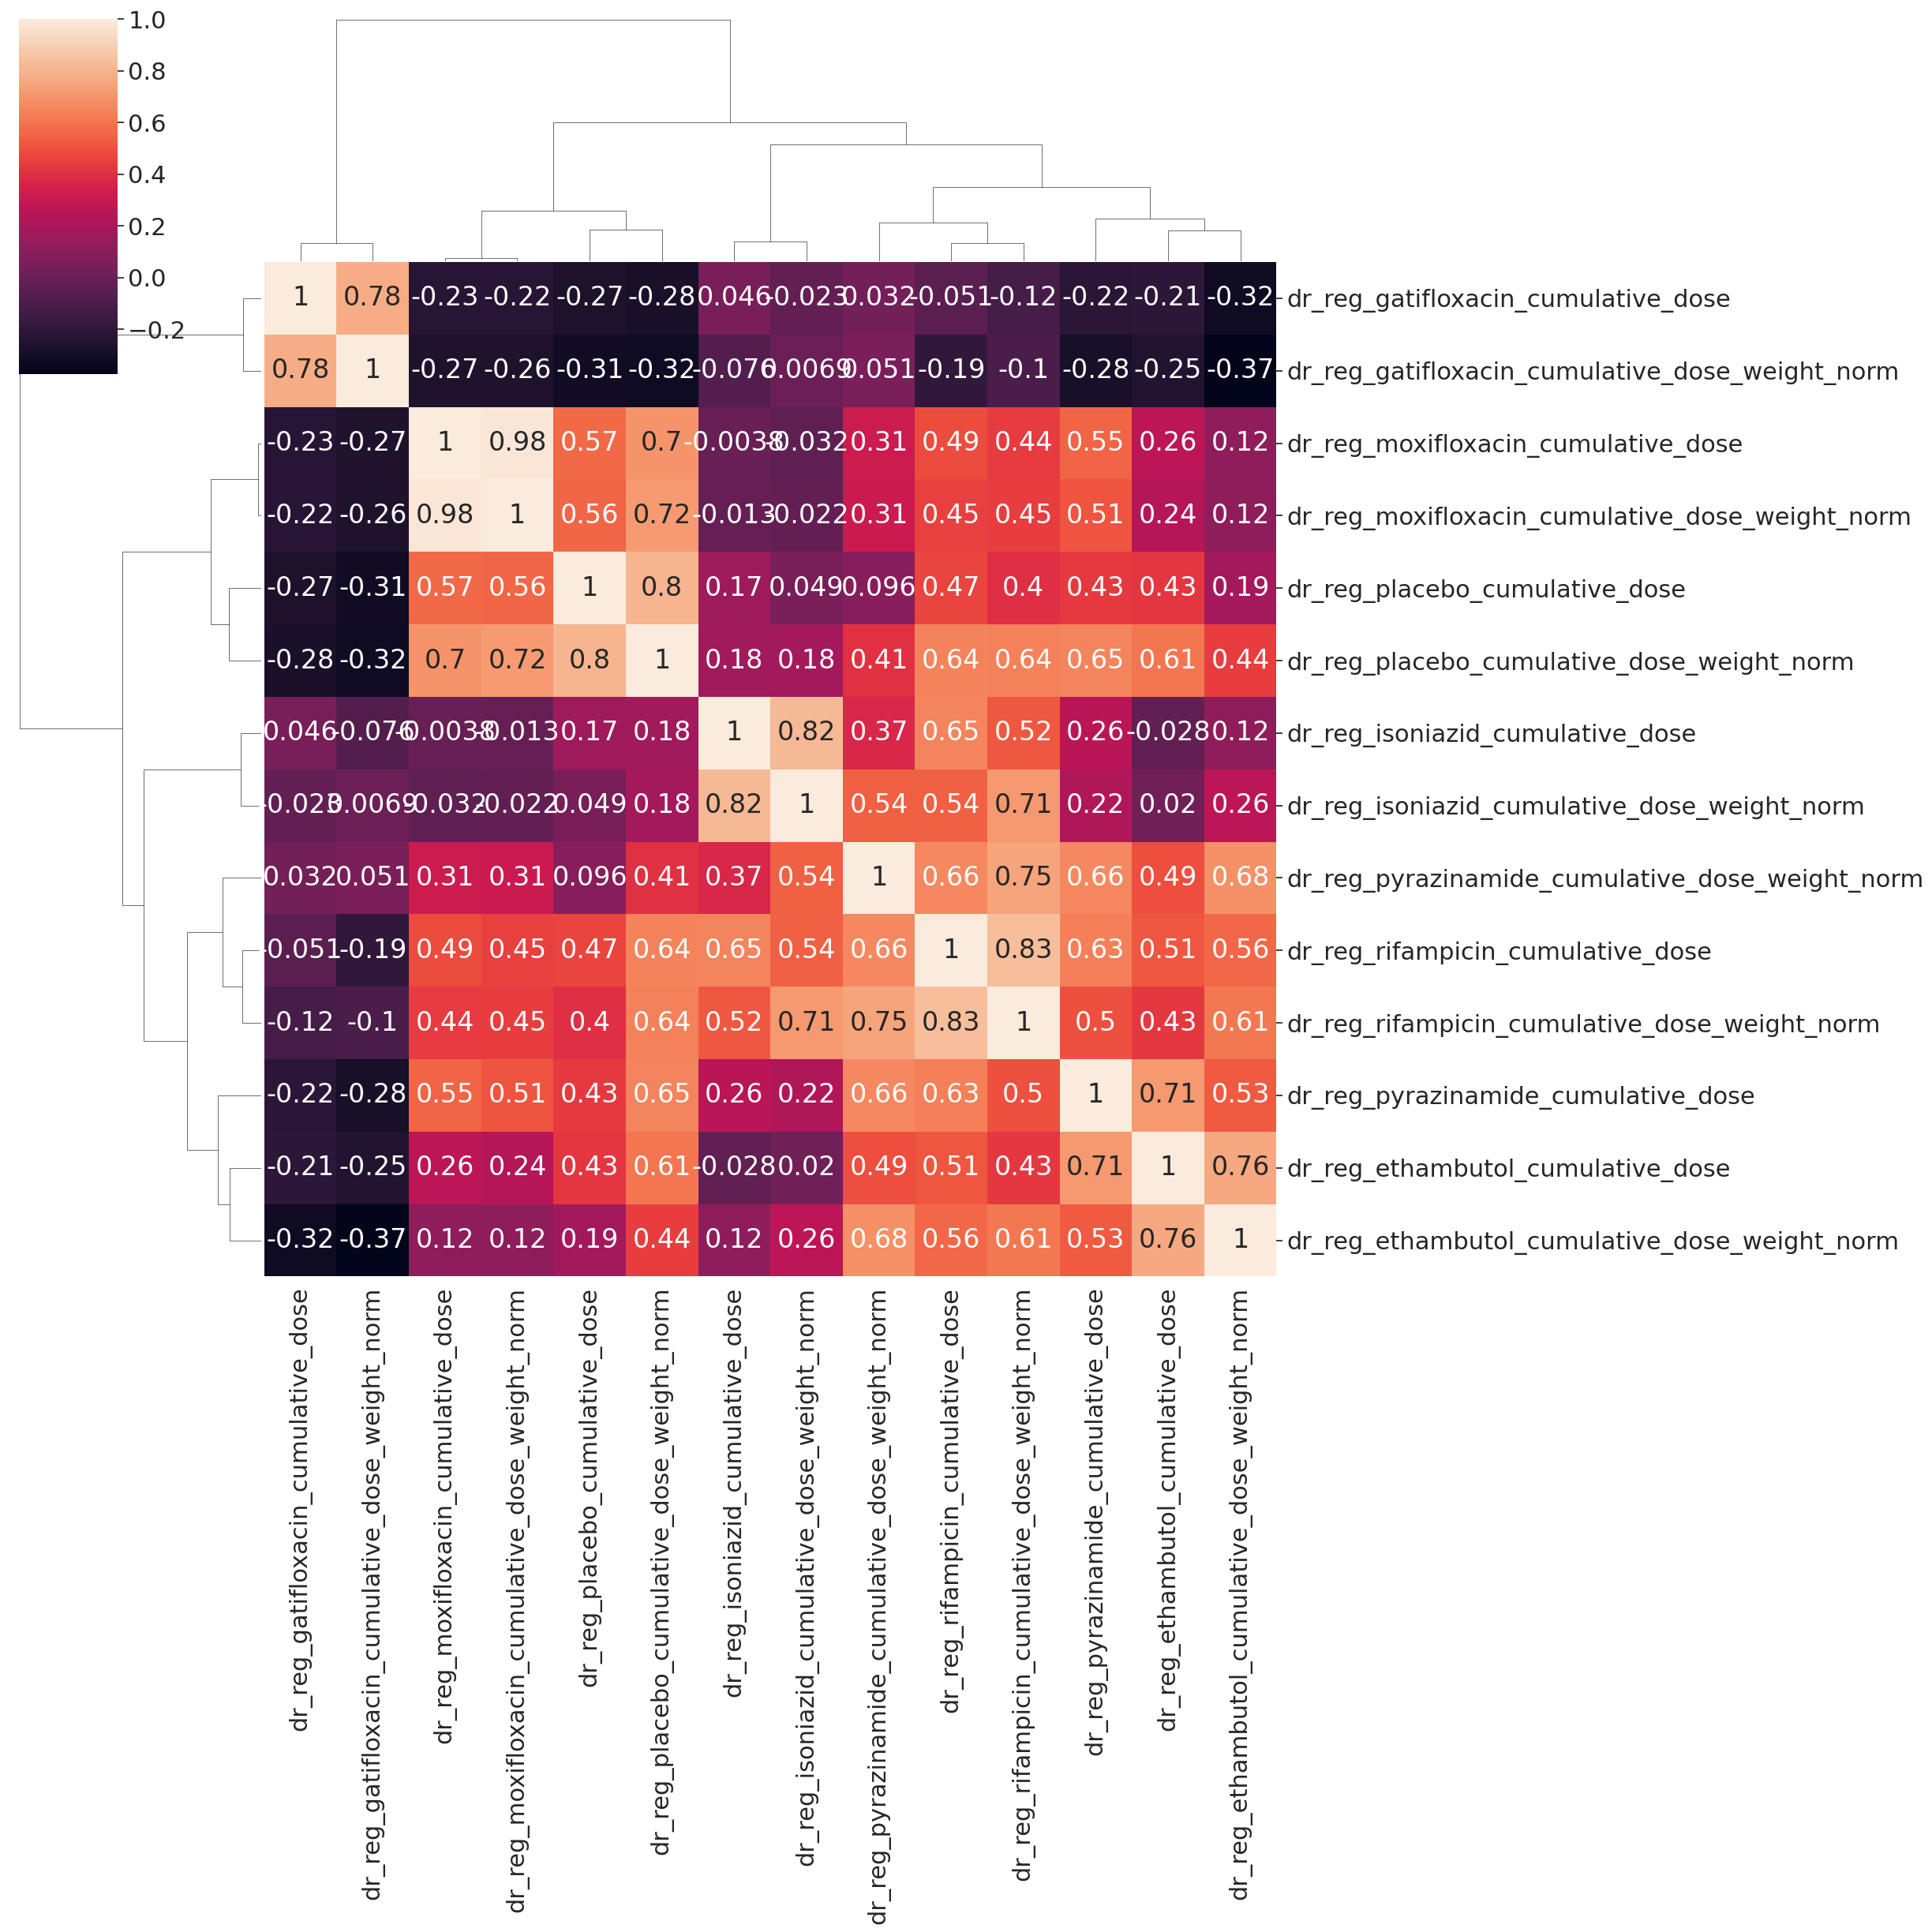

In [66]:
sns.clustermap(c[c.columns[c.columns.str.contains('cumulative_dose')]].dropna().corr().dropna(how='all',axis=1).dropna(how='all',axis=0),
               figsize=(25,25),
               annot=True,
               method='ward')

In [39]:
c.groupby('USUBJID').apply(lambda x:x[drug_cols].cumsum())

dr_reg_pyrazinamide  dr_reg_rifapentine   
USUBJID                                                         
JNE1998/0001  754332                800.0                 0.0  \
              754333               1600.0                 0.0   
              754334               2400.0                 0.0   
              754335               3200.0                 0.0   
              754336               4000.0                 0.0   
...                                   ...                 ...   
TB-1022/53506 928083              76800.0                 0.0   
              928084              76800.0                 0.0   
              928085              76800.0                 0.0   
              928086              76800.0                 0.0   
              928087              76800.0                 0.0   

                      dr_reg_ethambutol  dr_reg_rifampicin   
USUBJID                                                      
JNE1998/0001  754332              600.0              300.0  \
              754333             1200.0              600.0   
              754334             1800.0              900.0   
              754335             2400.0             1200.0   
              754336             3000.0             1500.0   
...                                 ...                ...   
TB-1022/53506 928083                0.0            57600.0   
              928084                0.0            57600.0   
              928085                0.0            57600.0   
              928086                0.0            57600.0   
              928087                0.0            57600.0   

                      dr_reg_moxifloxacin  dr_reg_placebo  dr_reg_isoniazid   
USUBJID                                                                       
JNE1998/0001  754332                  0.0             0.0             200.0  \
              754333                  0.0             0.0             400.0   
              754334                  0.0             0.0             600.0   
              754335                  0.0             0.0             800.0   
              754336                  0.0             0.0            1000.0   
...                                   ...             ...               ...   
TB-1022/53506 928083                  0.0             0.0           28800.0   
              928084                  0.0             0.0           28800.0   
              928085                  0.0             0.0           28800.0   
              928086                  0.0             0.0           28800.0   
              928087                  0.0             0.0           28800.0   

                      dr_reg_linezolid  dr_reg_bedaquiline  dr_reg_pretomanid   
USUBJID                                                                         
JNE1998/0001  754332               0.0                 0.0                0.0  \
              754333               0.0                 0.0                0.0   
              754334               0.0                 0.0                0.0   
              754335               0.0                 0.0                0.0   
              754336               0.0                 0.0                0.0   
...                                ...                 ...                ...   
TB-1022/53506 928083               0.0                 0.0                0.0   
              928084               0.0                 0.0                0.0   
              928085               0.0                 0.0                0.0   
              928086               0.0                 0.0                0.0   
              928087               0.0                 0.0                0.0   

                      dr_reg_gatifloxacin  
USUBJID                                    
JNE1998/0001  754332                  0.0  
              754333                  0.0  
              754334                  0.0  
              754335                  0.0  
              754336   

In [3]:
temporal_pat_regimens.columns[temporal_pat_regimens.columns.str.contains('cumul')]

Index(['dr_reg_moxifloxacin_cumulative_dose',
       'dr_reg_ethambutol_cumulative_dose',
       'dr_reg_rifapentine_cumulative_dose',
       'dr_reg_rifampicin_cumulative_dose',
       'dr_reg_pyrazinamide_cumulative_dose', 'dr_reg_placebo_cumulative_dose',
       'dr_reg_isoniazid_cumulative_dose', 'dr_reg_pretomanid_cumulative_dose',
       'dr_reg_linezolid_cumulative_dose',
       'dr_reg_bedaquiline_cumulative_dose',
       'dr_reg_gatifloxacin_cumulative_dose', 'dr_reg_study_drugs_cumul'],
      dtype='object')

In [45]:
arm_df['dr_reg_study_drugs']

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
          ..
527334   NaN
527335   NaN
527336   NaN
527337   NaN
527338   NaN
Name: dr_reg_study_drugs, Length: 44954, dtype: float64

In [56]:
arm_df.loc[(arm_df[study_drug_colnames]>0).any(axis=1),:]

,DAY,USUBJID,STUDYID,Arm,Week,dr_reg_rifapentine_weekly_freq,dr_reg_rifapentine,dr_reg_ethambutol_weekly_freq,dr_reg_ethambutol,dr_reg_pyrazinamide_weekly_freq,...,dr_reg_amikacin,dr_reg_aminosalicylic-acid,dr_reg_terizidone,dr_reg_syrup isoniazid,dr_reg_gatifloxacin_weekly_freq,dr_reg_gatifloxacin,dr_reg_gatifloxacin_num_of_doses,dr_reg_gatifloxacin_cumulative_dose,dr_reg_study_drugs,dr_reg_study_drugs_cumul
0,1.0,TB-1020/6034,TB-1020,"Study Regimen 1: 2 months of daily ethambutol,...",1.0,0.0,0.0,7.0,800.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,2.0,TB-1020/6034,TB-1020,"Study Regimen 1: 2 months of daily ethambutol,...",1.0,0.0,0.0,7.0,800.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,3.0,TB-1020/6034,TB-1020,"Study Regimen 1: 2 months of daily ethambutol,...",1.0,0.0,0.0,7.0,800.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
3,4.0,TB-1020/6034,TB-1020,"Study Regimen 1: 2 months of daily ethambutol,...",1.0,0.0,0.0,7.0,800.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
4,5.0,TB-1020/6034,TB-1020,"Study Regimen 1: 2 months of daily ethambutol,...",1.0,0.0,0.0,7.0,800.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
527266,110.0,TB-1020/4226,TB-1020,"Study Regimen 1: 2 months of daily ethambutol,...",16.0,2.0,900.0,7.0,0.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
527270,114.0,TB-1020/4226,TB-1020,"Study Regimen 1: 2 months of daily ethambutol,...",17.0,2.0,900.0,7.0,0.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
527273,117.0,TB-1020/4226,TB-1020,"Study Regimen 1: 2 months of daily ethambutol,...",17.0,2.0,900.0,7.0,0.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
527277,121.0,TB-1020/4226,TB-1020,"Study Regimen 1: 2 months of daily ethambutol,...",18.0,2.0,900.0,7.0,0.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


In [51]:
(arm_df[study_drug_colnames])

,dr_reg_moxifloxacin,dr_reg_ethambutol,dr_reg_rifapentine,dr_reg_rifampicin,dr_reg_pyrazinamide
0,400.0,800.0,0.0,450.0,1500.0
1,400.0,800.0,0.0,450.0,1500.0
2,400.0,800.0,0.0,450.0,1500.0
3,400.0,800.0,0.0,450.0,1500.0
4,400.0,800.0,0.0,450.0,1500.0
...,...,...,...,...,...
527334,0.0,0.0,0.0,0.0,0.0
527335,0.0,0.0,0.0,0.0,0.0
527336,0.0,0.0,0.0,0.0,0.0
527337,0.0,0.0,0.0,0.0,0.0


In [55]:
(arm_df[study_drug_colnames]>0).any(axis=1)

0          True
1          True
2          True
3          True
4          True
          ...  
527334    False
527335    False
527336    False
527337    False
527338    False
Length: 44954, dtype: bool